# Pair Trading Strategy

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

## 1. Data Collection
We download daily closing prices for AAPL and MSFT using yfinance.

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import compute_zscore  

# Select assets
tickers = ["AAPL", "MSFT"]

# Download Data
data = yf.download(tickers, start="2023-01-01", end="2024-01-01")["Close"]

# Cleand data
data.dropna(inplace=True)

[*********************100%***********************]  2 of 2 completed


## 2. Spred Construction
We define the spread as the difference between the prices of the two assets.

In [4]:
import numpy as np

data["spread"] = np.log(data[tickers[0]]) - np.log(data[tickers[1]])

## 3. Z-Score Normalization
The spread is normalized using a z-score to identify deviations from the mean.

In [5]:
data["zscore"] = compute_zscore(data["spread"])

## 4. Signal Generation
We generate trading signals based on z-score thresholds.

In [6]:
entry_threshold = 1.0
exit_threshold = 0.0

data['position'] = 0

# Entry signals
data.loc[data["zscore"] > entry_threshold, "position"] = -1
data.loc[data["zscore"] < -entry_threshold, "position"] = 1

# Forward fill positions
data["position"] = data["position"].ffill()

# Exit signals
data.loc[data["zscore"].abs() < exit_threshold, "position"] = 0

## 5. Backtest
We compute strategy return based on spread changes and positions.

In [7]:
# Spread returns
data["spread_returns"] = data["spread"].diff()

# Strategy returns
data["strategy_returns"] = data["position"].shift(1) * data["spread_returns"]

# Cumulative strategy returns
data["cumulative_strategy_returns"] = data["strategy_returns"].cumsum()

## 6. Results
We visualize the spread, z-score and cumulative returns.

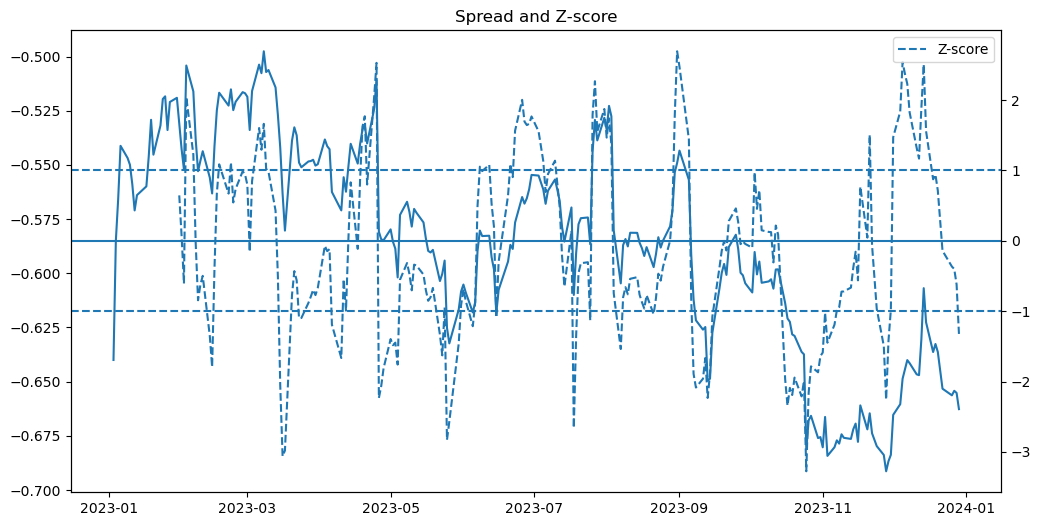

In [8]:
plt.figure(figsize=(12,6))

# Spread
plt.plot(data['spread'], label='Spread')

# Z-score and second axis
ax2 = plt.gca().twinx()
ax2.plot(data["zscore"], linestyle="--", label="Z-score")

# Thresholds
ax2.axhline(1.0, linestyle="--")
ax2.axhline(-1.0, linestyle="--")
ax2.axhline(0)

plt.title("Spread and Z-score")
plt.legend(loc="upper left")
ax2.legend(loc="upper right")

# Save figure in figures/ folder
plt.savefig("../figures/spread_zscore.png", bbox_inches='tight')

plt.show()

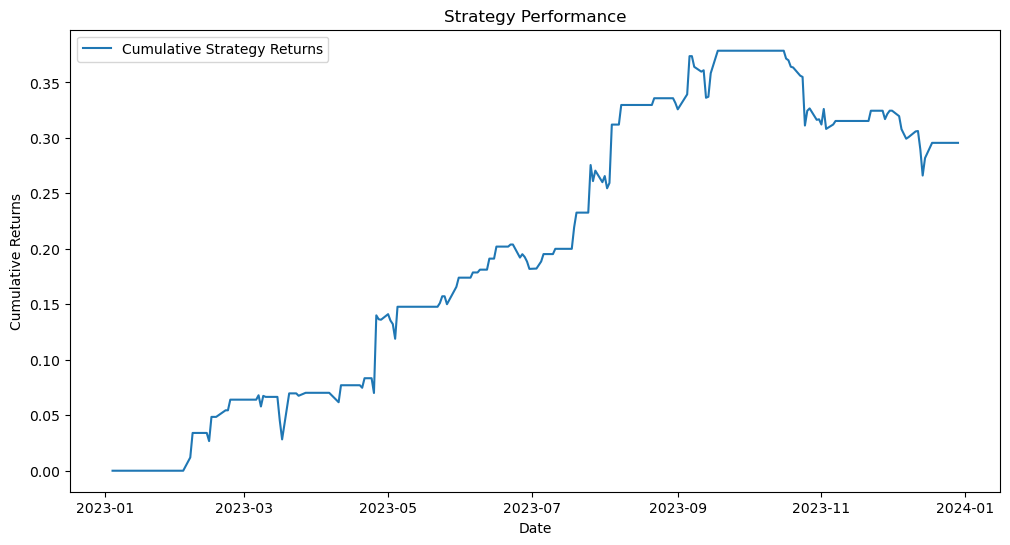

In [9]:
plt.figure(figsize=(12,6))

plt.plot(data['cumulative_strategy_returns'], label='Cumulative Strategy Returns')

plt.title("Strategy Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.legend()

# Save figure in figures/ folder
plt.savefig("../figures/cumulative_returns.png", bbox_inches='tight')

plt.show()

In [11]:
import numpy as np

returns = data["strategy_returns"].dropna()

# Sharpe Ratio (annualisé)
sharpe = np.sqrt(252) * returns.mean() / returns.std()

# Return total
cum_return = returns.sum()

# Volatitlité annualisée
volatility = returns.std() * np.sqrt(252)

# Max Drawdown
cum_returns = returns.cumsum()
running_max = cum_returns.cummax()
drawdown = cum_returns - running_max
max_drawdown = drawdown.min()

print(f"Sharpe Ratio: {sharpe: .2f}")
print(f"Cumulative Return: {cum_return: .4f}")
print(f"Volatility: {volatility: .4f}")
print(f"Max Drawdown: {max_drawdown: .4f}")

Sharpe Ratio:  1.88
Cumulative Return:  0.2955
Volatility:  0.1589
Max Drawdown: -0.1125


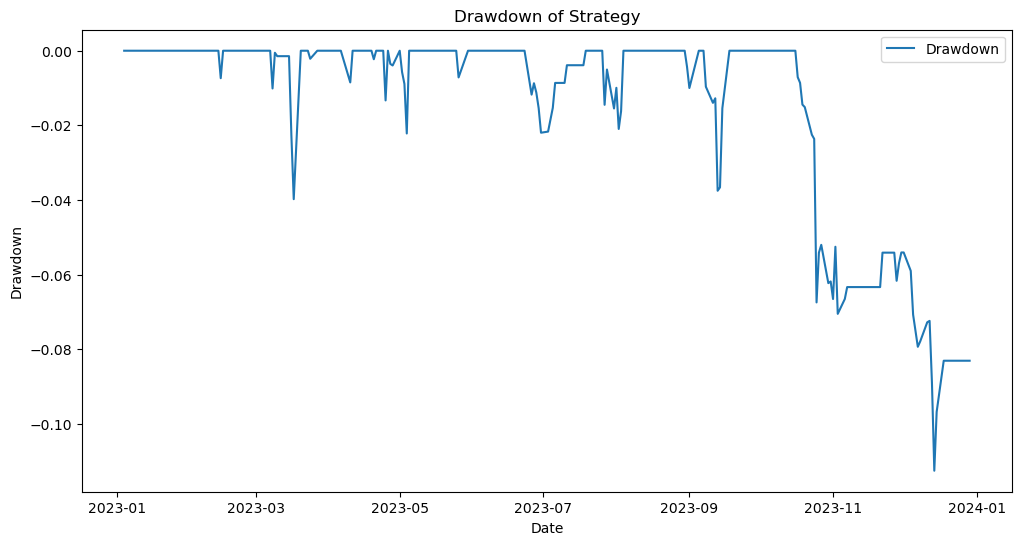

In [13]:
plt.figure(figsize=(12,6))
plt.plot(drawdown, label="Drawdown")

plt.title("Drawdown of Strategy")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.legend()
plt.show()

## Performance Analysis
The Strategy exhibits positive risk-adjusted returns with a Sharpe ratio of 1.88.
However, this performance is likely overstated due to the absence of transaction costs and statistical validation (e.g. cointegration). Results should therefore be interpreted with caution.